In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ankulsharma150/netflix-data-analysis")

print("Path to dataset files:", path)

100%|██████████| 1.34M/1.34M [00:01<00:00, 1.31MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/ankulsharma150/netflix-data-analysis/versions/1


In [16]:
!pip install pandasql

  Preparing metadata (setup.py) ... done
  Created wheel for pandasql: filename=pandasql-0.7.3-py3-none-any.whl size=26773 sha256=8b84332ace550a374edf11891b9e87f6b9d1a5c70c15f16b3fd9fe66707209f5
  Stored in directory: /root/.cache/pip/wheels/15/a1/e7/6f92f295b5272ae5c02365e6b8fa19cb93f16a537090a1cf27
Successfully built pandasql


**Анализ контента Netflix**

В ходе исследования набора датасета Netflix были проанализированы тренды добавления контента, его типы, жанры и ключевые участники (актеры и режиссеры). Для анализа использовались библиотеки Python (Pandas) и SQL-запросы через pandasql.


In [1]:
import zipfile

with zipfile.ZipFile('/content/archive.zip', 'r') as z:
    z.extractall('/content/dlya.net')

In [24]:
import pandas as pd
df = pd.read_csv("/content/dlya.net/netflix_movies (1).csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8807 non-null   object        
 1   type          8807 non-null   object        
 2   title         8807 non-null   object        
 3   director      6173 non-null   object        
 4   cast          7982 non-null   object        
 5   country       7976 non-null   object        
 6   date_added    8797 non-null   datetime64[ns]
 7   release_year  8807 non-null   int64         
 8   rating        8803 non-null   object        
 9   duration      8804 non-null   object        
 10  listed_in     8807 non-null   object        
 11  description   8807 non-null   object        
 12  month_added   8797 non-null   object        
 13  year_added    8797 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(11)
memory usage: 963.4+ KB


In [33]:
df.shape

(8807, 14)

Show the all Movies & TV Shows released by month

Показать все фильмы и телешоу, вышедшие по месяцам


*   Извлекаем месяц
*   Группируем данные по месяцу и типу контента, чтобы месяцы шли по порядку создаем список для сортировки
*   Сортируем по календарному порядку
*   Добавляем колонку TOTAL для наглядности




In [25]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['month_added'] = df['date_added'].dt.month_name()

months_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

result = df.groupby(['month_added', 'type']).size().unstack(fill_value=0)

result = result.reindex(months_order)

result['Total'] = result.sum(axis=1)

print("Статистика добавления контента по месяцам:")
print(result)

Статистика добавления контента по месяцам:
type         Movie  TV Show  Total
month_added                       
January        546      192    738
February       382      181    563
March          529      213    742
April          550      214    764
May            439      193    632
June           492      236    728
July           565      262    827
August         519      236    755
September      519      251    770
October        545      215    760
November       498      207    705
December       547      266    813


Count the all types of unique rating & which rating are with most number

Подсчитайте все типы уникальных рейтингов и укажите, какой рейтинг имеет наибольшее количество баллов


*   Подсчет уникальных рейтингов
*   Поиск самого популярного рейтинга



In [27]:
# Подсчет уникальных рейтингов
unique_ratings_count = df['rating'].nunique()
unique_ratings_list = df['rating'].unique()

# Поиск самого популярного рейтинга
rating_counts = df['rating'].value_counts()
most_popular_rating = rating_counts.idxmax()
most_popular_count = rating_counts.max()

print(f"Количество уникальных типов рейтинга: {unique_ratings_count}")
print("-" * 30)
print("Топ-5 рейтингов по количеству контента:")
print(rating_counts.head(5))
print("-" * 30)
print(f"Самый популярный рейтинг: {most_popular_rating} ({most_popular_count} видео)")

# Cписок всех уникальных рейтингов:
print("Все типы рейтингов:", unique_ratings_list)

Количество уникальных типов рейтинга: 17
------------------------------
Топ-5 рейтингов по количеству контента:
rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
Name: count, dtype: int64
------------------------------
Самый популярный рейтинг: TV-MA (3207 видео)
Все типы рейтингов: ['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' '74 min' '84 min' '66 min' 'NR' nan 'TV-Y7-FV' 'UR']


Find out the Movies & Series have Maximum time length

Какие фильмы и сериалы имеют максимальную продолжительность по времени


*   Находим самый длинный фильм
*   Находим самый продолжительное телешоу



In [29]:
# FIND LONGEST MOVIE
movies = df[df['type'] == 'Movie'].copy()

movies['duration_num'] = movies['duration'].str.extract(r'(\d+)').astype(float)
longest_movie = movies.nlargest(1, 'duration_num')

# FIND LONGEST TV SHOW
tv_shows = df[df['type'] == 'TV Show'].copy()

tv_shows['season_count'] = tv_shows['duration'].str.extract(r'(\d+)').astype(float)
longest_show = tv_shows.nlargest(1, 'season_count')

print(f"Самый длинный фильм: {longest_movie['title'].values[0]} ({int(longest_movie['duration_num'].values[0])} мин)")
print(f"Самый продолжительное телешоу: {longest_show['title'].values[0]} ({int(longest_show['season_count'].values[0])} сезонов)")

Самый длинный фильм: Black Mirror: Bandersnatch (312 мин)
Самый продолжительное телешоу: Grey's Anatomy (17 сезонов)


Year on Year show added on Netflix by its type

Сколько в год шоу добавляются на Netflix в разбивке по типу


*   Очищаем 'date_added' и извлекаем год
*    Сгруппируем по годам и типам (игнорируя годы до 2010 года для получения более четкой диаграммы)




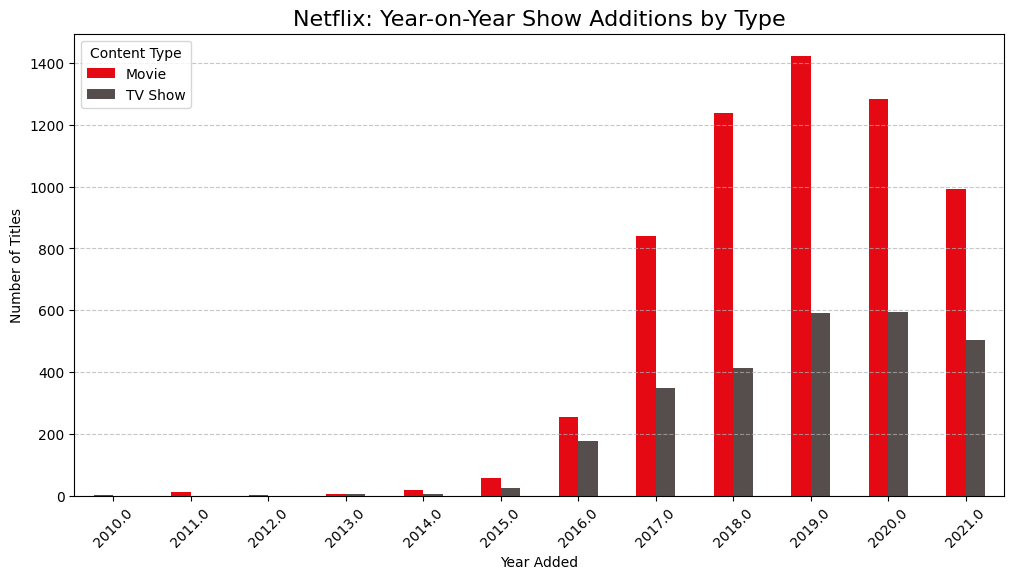

type        Movie  TV Show
year_added                
2010.0          1        0
2011.0         13        0
2012.0          3        0
2013.0          6        5
2014.0         19        5
2015.0         56       26
2016.0        253      176
2017.0        839      349
2018.0       1237      412
2019.0       1424      592
2020.0       1284      595
2021.0        993      505


In [30]:
import matplotlib.pyplot as plt

# Clean 'date_added' and extract the year
df['date_added'] = pd.to_datetime(df['date_added'].astype(str).str.strip(), errors='coerce')
df['year_added'] = df['date_added'].dt.year.dropna().astype(int)

# Group by year and type (ignoring years before 2010 for a cleaner chart)
yearly_counts = df[df['year_added'] >= 2010].groupby(['year_added', 'type']).size().unstack(fill_value=0)

# Plotting the data
yearly_counts.plot(kind='bar', figsize=(12, 6), color=['#E50914', '#564d4d'])
plt.title('Netflix: Year-on-Year Show Additions by Type', fontsize=16)
plt.ylabel('Number of Titles')
plt.xlabel('Year Added')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Content Type')
plt.show()

# Display the summary table
print(yearly_counts)

Who Director has made the most TV Shows

Кто из режиссеров снял больше всего телешоу


*   Превращаем файл CSV в объект DataFrame
*   SQL-запросе мы будем обращаться к нему просто по имени переменной — df



In [19]:
from pandasql import sqldf

# Функция для удобного вызова SQL
pysqldf = lambda q: sqldf(q, globals())

# Пишем SQL запрос
query = """
SELECT
    director,
    COUNT(*) as total_count
FROM df
WHERE type = 'TV Show' AND director IS NOT NULL
GROUP BY director
ORDER BY total_count desc
LIMIT 5;
"""

# Выполняем запрос
result = pysqldf(query)

print("Топ режиссеров ТВ-шоу (через SQL запрос):")
print(result)

Топ режиссеров ТВ-шоу (через SQL запрос):
              director  total_count
0  Alastair Fothergill            3
1          Stan Lathan            2
2          Shin Won-ho            2
3      Rob Seidenglanz            2
4            Ken Burns            2


Actors and Actress who have given most Number of Movies

Актеры и актрисы, снявшиеся в наибольшем количестве фильмов
*  Фильтруем только фильмы и убираем строки, где актеры не указаны
*  Разделяем имена (из строки в список) и превращаем список в отдельные строки (explode)




In [20]:
# Фильтруем только фильмы и убираем строки, где актеры не указаны
movies = df[df['type'] == 'Movie'].dropna(subset=['cast'])

# Разделяем имена и превращаем список в отдельные строки
top_actors = movies['cast'].str.split(', ').explode().value_counts()

print("Актеры с наибольшим количеством фильмов на Netflix:")
print(top_actors.head(10))

Актеры с наибольшим количеством фильмов на Netflix:
cast
Anupam Kher         42
Shah Rukh Khan      35
Naseeruddin Shah    32
Akshay Kumar        30
Om Puri             30
Paresh Rawal        28
Julie Tejwani       28
Amitabh Bachchan    28
Boman Irani         27
Rupa Bhimani        27
Name: count, dtype: int64


Find out which types of genre has most movies and TV Shows

К каким жанрам относится большинство фильмов и телешоу

In [31]:
def get_top_genres(data_type):
    filtered_df = df[df['type'] == data_type].dropna(subset=['listed_in'])
    genres = filtered_df['listed_in'].str.split(', ').explode()

    return genres.value_counts().head(5)

print("САМЫЕ ПОПУЛЯРНЫЕ ЖАНРЫ НА NETFLIX")
print("-" * 40)
print("ТОП-5 ЖАНРОВ КИНО (Movies):")
print(get_top_genres('Movie'))

print("\nТОП-5 ЖАНРОВ СЕРИАЛОВ (TV Shows):")
print(get_top_genres('TV Show'))

САМЫЕ ПОПУЛЯРНЫЕ ЖАНРЫ НА NETFLIX
----------------------------------------
ТОП-5 ЖАНРОВ КИНО (Movies):
listed_in
International Movies    2752
Dramas                  2427
Comedies                1674
Documentaries            869
Action & Adventure       859
Name: count, dtype: int64

ТОП-5 ЖАНРОВ СЕРИАЛОВ (TV Shows):
listed_in
International TV Shows    1351
TV Dramas                  763
TV Comedies                581
Crime TV Shows             470
Kids' TV                   451
Name: count, dtype: int64
